# **臺灣現存大專院校未來退場機率預測**

> **機器學習 期末專題**

* 國立彰化師範大學 資訊工程學系 S1254059 吳佳泰
* 國立彰化師範大學 資訊工程學系 S1254061 潘彥霖

---

### **使用說明**
* 使用 Google Colab 執行前需先掛接 [university_data.csv](https://drive.google.com/file/d/13HyOXm4acnnKeNu2lM3rexNBt0cvwlo1/view?usp=sharing) 與 [university_data_test.csv](https://drive.google.com/file/d/1mWUKdGfs2Nkdl5hOlrkLQ88EVoSwKL_3/view?usp=sharing) 檔案
* 執行完畢會輸出 **113_data_prediction_result.csv** 檔案

## Step1. 安裝所需套件

In [37]:
!pip install pandas
!pip install scikit-learn
!pip install numpy

## Step2. 匯入所需模組與資料


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

university_data = pd.read_csv("university_data.csv")
university_data_test = pd.read_csv("university_data_test.csv")

# leave school_name to predict output data :D
test_school_names = university_data_test["school_name"].copy()

## Step3. 資料預處理

* 去除無用欄位
* 針對學校總類編號

In [39]:
# all columns : id,data_year,school_name,private_flag,school_type,school_region,urbanization_level,enrollment_quota,new_student_count,enrollment_rate,tuition_revenue_ratio,debt_ratio,net_income_ratio,totur_flag,closure_flag
# need columns: private_flag,school_type,school_region,urbanization_level,enrollment_quota,new_student_count,enrollment_rate,tuition_revenue_ratio,debt_ratio,net_income_ratio,totur_flag,closure_flag

# drop useless data
university_data = university_data.drop(columns=["id", "data_year", "school_name", "school_region"])
university_data_test = university_data_test.drop(columns=["id", "data_year", "school_name", "school_region"])

# encode school_type
encode = LabelEncoder()
university_data["school_type"] = encode.fit_transform(university_data["school_type"])
university_data_test["school_type"] = encode.transform(university_data_test["school_type"])

## Step4. 切分資料集與訓練集
* 切分資料集與訓練集
* 使用中位數補齊缺失值

In [40]:
X = university_data.drop("closure_flag", axis=1).values  # feature
y = university_data["closure_flag"].values  # label

test_X = university_data_test.drop("closure_flag", axis=1).values # feature
test_y = university_data_test["closure_flag"].values  # label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

imputer = SimpleImputer(strategy="median")  # complete : use midian
X_imputed = imputer.fit_transform(X)
X_test_imputed = imputer.transform(test_X)

## Step5. 卡方檢定

In [41]:
# DataFrame（only feature）
feature_cols = university_data.drop("closure_flag", axis=1).columns
df = pd.DataFrame(X, columns=feature_cols)

# type
cat_features = ["private_flag", "school_type", "urbanization_level", "totur_flag"]
X_cat = df[cat_features].values

# type complete
imputer_cat = SimpleImputer(strategy="most_frequent")
X_cat_imputed = imputer_cat.fit_transform(X_cat)

# Chi-Squared Test
chi2_scores, p_values = chi2(X_cat_imputed, y)

for f, score, p in zip(cat_features, chi2_scores, p_values):
    print(f"{f:<25} chi2={score:.2f}, p={p:.4f}")

private_flag              chi2=2.62, p=0.1056
school_type               chi2=1.62, p=0.2033
urbanization_level        chi2=11.15, p=0.0008
totur_flag                chi2=134.03, p=0.0000


## Step6. 模型比較

In [42]:
# pre-processing
preprocess_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# equip pipeline
models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocess_pipeline),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    "SVM (RBF)": Pipeline([
        ("preprocess", preprocess_pipeline),
        ("model", SVC(kernel="rbf", class_weight="balanced", probability=True))
    ]),
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(n_estimators=200, scale_pos_weight=3, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
    ])
}

# cross-vaildation
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"{name:<20} Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression  Accuracy: 0.9346 (+/- 0.0169)
SVM (RBF)            Accuracy: 0.9452 (+/- 0.0154)
XGBoost              Accuracy: 0.9779 (+/- 0.0039)
Random Forest        Accuracy: 0.9837 (+/- 0.0023)


## Step7. 隨機森林 - 下採樣

In [43]:
# merge to DataFrame
df_train = pd.DataFrame(X, columns=university_data.drop("closure_flag", axis=1).columns)
df_train['closure_flag'] = y

# sparate
df_closure = df_train[df_train['closure_flag'] == 1]
df_normal = df_train[df_train['closure_flag'] == 0]

# sample
df_normal_sampled = df_normal.sample(n=len(df_closure)*3, random_state=42)

# balance
df_balanced = pd.concat([df_closure, df_normal_sampled]).sample(frac=1, random_state=42)

X_balanced = df_balanced.drop('closure_flag', axis=1).values
y_balanced = df_balanced['closure_flag'].values

# 5. train again
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=0)

## Step6. 建立模型

In [44]:
random_forest_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", oob_score=True, random_state=42)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       oob_score=True, random_state=42)

## Step7-1. 預測並驗證分析模型
* 普通評分 `random_forest_model.score()` : 訓練準確度、測試準確度、OOB分數、過擬合判斷
* 混淆矩陣 `metrics.classification_report()`
* 特徵重要性分析 `random_forest_model.feature_importances_`

In [45]:
# score
train_score = random_forest_model.score(X_train, y_train)
test_score = random_forest_model.score(X_test, y_test)
oob_score = random_forest_model.oob_score_

print("Train accuracy : ", train_score)
print("Test score : ", test_score)
print("OOB score : ", oob_score)
print("Overfitting judge: ", train_score - test_score, "(OK)") if (train_score - test_score < 0.5) else print("Overfitting : ", train_score - test_score, "(overfitting)")

print("\n---------------------------------------------------\n")

# matrix
predict = random_forest_model.predict(X_test)
print(metrics.classification_report(y_test, predict))

print("\n---------------------------------------------------\n")

# feature importance
importances = random_forest_model.feature_importances_
features = university_data.drop("closure_flag", axis=1).columns
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.4f}")

Train accuracy :  1.0
Test score :  0.7857142857142857
OOB score :  0.8703703703703703
Overfitting judge:  0.2142857142857143 (OK)

---------------------------------------------------

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       0.50      0.67      0.57         3

    accuracy                           0.79        14
   macro avg       0.70      0.74      0.71        14
weighted avg       0.81      0.79      0.80        14


---------------------------------------------------

private_flag: 0.0021
school_type: 0.0034
urbanization_level: 0.0863
enrollment_quota: 0.2149
new_student_count: 0.3305
stability: 0.0642
enrollment_rate: 0.1605
tuition_revenue_ratio: 0.0476
debt_ratio: 0.0417
net_income_ratio: 0.0467
totur_flag: 0.0021


## Step7-2. 資料可視化

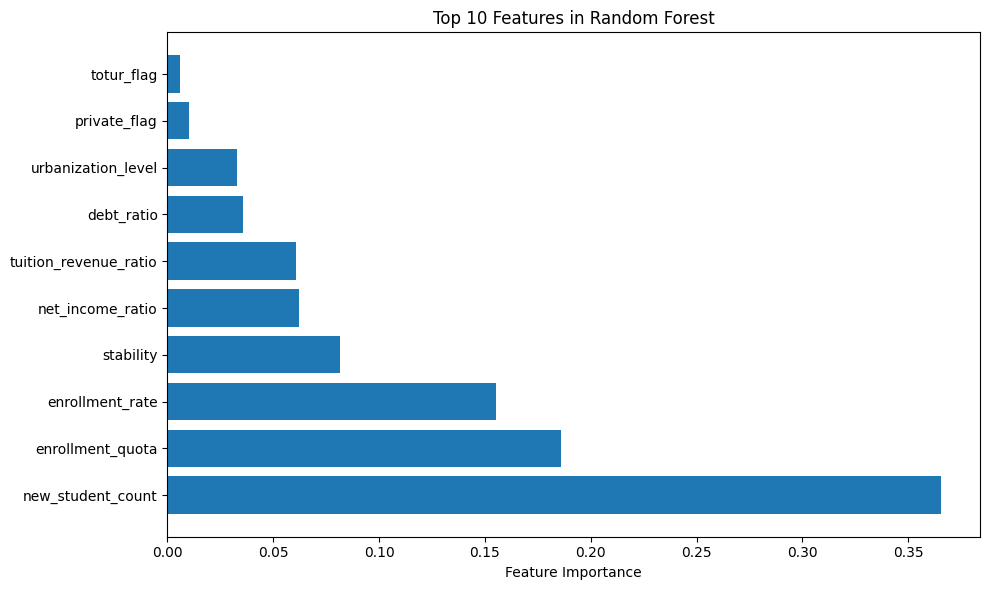

In [46]:
# feature names
features = university_data.drop("closure_flag", axis=1).columns

# random forests model
rf_obj = models["Random Forest"]

# if pipeline, take the final model out, else model self
if isinstance(rf_obj, Pipeline):
    rf_obj.fit(X, y)  # 或 X_train, y_train
    rf_model = rf_obj.named_steps["model"]
else:
    rf_model = rf_obj
    rf_model.fit(X, y)

# features importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

# chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices])
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([features[i] for i in indices])
ax.set_xlabel("Feature Importance")
ax.set_title("Top 10 Features in Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

## Step8-1. 預測新資料並輸出

In [47]:
test_pred = random_forest_model.predict(test_X)
test_pred_proba = random_forest_model.predict_proba(test_X)[:, 1]

result = pd.DataFrame({"School_Name": test_school_names, "True_Label": test_y, "Predicted_Label": test_pred, "Closure_Probability": test_pred_proba})

# reslit explanation
result["Prediction_Result"] = result.apply(lambda row: "correct" if row["True_Label"] == row["Predicted_Label"] else "error", axis=1)
result["Risk_Level"] = result["Closure_Probability"].apply(lambda x: "high" if x >= 0.7 else ("midterm" if x >= 0.4 else "low"))
result = result.sort_values('Closure_Probability', ascending=False)

# output file
print(result)
result.to_csv("113_data_prediction_results.csv", index=False, encoding="utf-8-sig")
print("All data is saved. You can check it in 113_data_prediction_results.csv.")

print("\n---------------------------------------------------\n")

# output score
print("Closure = 1 in 114 data：", np.sum(test_y == 1),)
print("Closure = 1 in our model：", np.sum(test_pred == 1))
print("Correct predict closure school：", np.sum((test_y == 1) & (test_pred == 1)))

        School_Name  True_Label  Predicted_Label  Closure_Probability  \
113      慈惠醫護管理專科學校           0                1                0.920   
68             真理大學           0                1                0.715   
114      敏惠醫護管理專科學校           0                1                0.715   
97   台鋼學校財團法人台鋼科技大學           0                1                0.705   
127      聖母醫護管理專科學校           0                1                0.670   
..              ...         ...              ...                  ...   
89   健行學校財團法人健行科技大學           0                0                0.000   
80           高雄醫學大學           0                0                0.000   
107          嶺東科技大學           0                0                0.000   
124  正修學校財團法人正修科技大學           0                0                0.000   
130  致理學校財團法人致理科技大學           0                0                0.000   

    Prediction_Result Risk_Level  
113             error       high  
68              error       high  
114             er

## Step8-2. 保存卡方檢定結果

In [48]:
chi2_results = pd.DataFrame({
    'Feature': cat_features,
    'Chi2_Score': chi2_scores,
    'P_Value': p_values,
    'Significant': ['Yes' if p < 0.05 else 'No' for p in p_values]
})

print(chi2_results.to_string(index=False))
chi2_results.to_csv("chi2_test_results.csv", index=False)

           Feature  Chi2_Score      P_Value Significant
      private_flag    2.619525 1.055561e-01          No
       school_type    1.618314 2.033271e-01          No
urbanization_level   11.148000 8.412232e-04         Yes
        totur_flag  134.033562 5.371965e-31         Yes
